In [5]:
import qiskit

# VQE Step 1: The Core Problem

## 1. The Physics: Everything Wants to be Lazy

Think about a ball placed on the side of a steep hill. What does it do? It rolls down until it hits the absolute lowest point in the valley and stops.

Nature is fundamentally lazy. Every molecule and atom in the universe wants to rest at its lowest possible energy state. In quantum mechanics, we call this the **Ground State Energy**, mathematically written as $E_0$.

If scientists know the exact ground state energy of a molecule, they understand how that molecule behaves, how it reacts with other chemicals, and how to use it to invent new medicines or better batteries.

## 2. The Problem: The Exploding Calculations

To find this lowest energy, we have to calculate the interactions between every single electron in the molecule.

* For a tiny molecule like Hydrogen, a classical laptop can calculate it easily.
* For a slightly larger molecule like Penicillin or Caffeine, the number of interactions explodes exponentially. A classical supercomputer would run out of memory before finishing the calculation.

## 3. The VQE Analogy: The Blindfolded Hiker

Since classical computers can't calculate the whole map, VQE uses a clever trick. Imagine you are dropped onto a mountain range **blindfolded**, and your goal is to find the lowest valley.

Here is how you do it using the VQE teamwork method:

* **The Quantum Computer (Your Legs):** You walk to a random coordinate on the mountain. (This is the quantum guess).
* **The Measurement (Your Altimeter):** You check an altimeter to see exactly how high up you are. (Measuring the energy).
* **The Classical Computer (Your Brain):** Your brain feels the slope of the ground under your feet. It says, *"The ground is sloping downward to the left. Let's take a step to the left!"* (The classical optimizer).

You repeat this loop—stepping, checking height, feeling the slope—until you reach a flat valley floor where you can't go down any further. You just found the Ground State!



# VQE Step 2: The Ansatz (The Quantum Guess)

## 1. Theory: Circuits with Adjustable Dials

So far, every circuit we have built (Deutsch, Grover, Shor) used fixed gates. An `H` gate or an `X` gate always does the exact same thing.

But for VQE, we need a flexible circuit. We build a circuit using **Parameterized Gates**.
Imagine replacing a fixed light switch with a dimmer dial. Instead of just flipping a qubit, we apply a rotation gate (like an RY gate) and give it an adjustable angle, let's call it `theta`.

**The Two Rules of a Good Chemistry Ansatz:**

1. **Rotations (The Dials):** We need adjustable rotation gates so our classical optimizer can twist the dials and change the quantum state slightly on each step.
2. **Entanglement (The Glue):** Electrons in a molecule interact with each other. If we change one electron, the others feel it. To simulate this, our Ansatz *must* include CNOT gates to entangle the qubits together.

---

## 2. Code: Building a Custom Ansatz from Scratch

Instead of using Qiskit's pre-built templates right away, let's build a custom 2-qubit Ansatz so your students can see exactly how the dials are created.

Our Custom Ansatz (The Guess Generator):


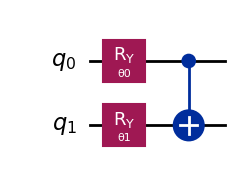

In [6]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

# --- 1. Create the Dials ---
# We define 'Parameters' instead of fixed numbers. 
# These are the variables the classical computer will adjust later.
theta_0 = Parameter('θ0')
theta_1 = Parameter('θ1')

# --- 2. Initialize Circuit ---
ansatz = QuantumCircuit(2)

# --- 3. Apply the Dials (Rotation Gates) ---
# We use RY gates (rotation around the Y-axis) and pass in our parameters.
ansatz.ry(theta_0, 0)
ansatz.ry(theta_1, 1)

# --- 4. Apply Entanglement ---
# We add a CNOT gate so the two qubits "talk" to each other,
# just like electrons in a real molecule.
ansatz.cx(0, 1)

# --- Visualize ---
print("Our Custom Ansatz (The Guess Generator):")
display(ansatz.draw('mpl'))



###  Mindmap: The VQE Architecture

* **The Core Objective:** Find the Ground State Energy (Lowest Energy of a Molecule)
* 
* **Part 1: The Quantum Setup (The Explorer)**
* **The Ansatz:** A parameterized quantum circuit template.
* *Rotations (RY, RX):* The adjustable dials for the classical computer to turn.
* *Entanglement (CNOTs):* The glue that mimics electrons interacting.





*  **Part 2: The Physics Environment (The Map & Altimeter)**
* **The Hamiltonian:** The mathematical representation of the molecule.
* *Pauli Strings:* Built using $X$, $Y$, and $Z$ gates to map chemical energies.


* **The Measurement:** The quantum computer runs the Ansatz and calculates the total energy score against the Hamiltonian.



* **Part 3: The Classical Loop (The Brain)**
* **The Cost Function:** The laptop receives the energy score.
* **The Optimizer:** Algorithms (like Gradient Descent or COBYLA) decide how to turn the dials.
* **The Feedback Loop:** Update the parameters $\rightarrow$ Run Quantum Circuit $\rightarrow$ Measure Energy $\rightarrow$ Repeat until the energy hits rock bottom!


# VQE Step 3: The Hamiltonian 

## 1. Theory: What is a Hamiltonian?

In our blindfolded hiker analogy, the hiker needs to know what mountain they are actually standing on. Are they on Mount Everest, or a small hill in a park?

In physics, the "mountain" is called the **Hamiltonian** (usually written as $H$). It is a mathematical model that describes the total energy of our specific molecule.

**How do we put a molecule into a quantum computer?**
Quantum computers only understand quantum gates. So, physicists figured out a way to translate chemical energies into combinations of Pauli gates ($X$, $Y$, $Z$, and $I$).

* We measure how the electrons spin and interact using strings of these gates, like `ZZ` or `XX`.
* We attach a "weight" to each string. For example, `1.0 * ZZ` means this specific interaction adds $1.0$ unit of energy to the system.

When the quantum computer measures our guess (the Ansatz) against this Hamiltonian map, it spits out an **Expectation Value**—which is just a fancy physics term for "Average Energy Score."

---

## 2. Code: Building the Hamiltonian

Let's use Qiskit to build a simple Hamiltonian for a 2-qubit system. We will use a tool called `SparsePauliOp`.





In [7]:
from qiskit.quantum_info import SparsePauliOp

# --- 1. Define the Physics Environment ---
# We create a list of tuples. 
# Each tuple has a Pauli string and its corresponding energy weight.
# Let's say our toy molecule is defined by a strong ZZ interaction
# and a weaker, negative XX interaction.
pauli_terms = [
    ("ZZ", 1.0), 
    ("XX", -0.5)
]

# --- 2. Create the Observable (Hamiltonian) ---
hamiltonian = SparsePauliOp.from_list(pauli_terms)

print("Our Molecule's Hamiltonian (The Mountain Map):")
print(hamiltonian)

Our Molecule's Hamiltonian (The Mountain Map):
SparsePauliOp(['ZZ', 'XX'],
              coeffs=[ 1. +0.j, -0.5+0.j])



---

## 3. Exercises (Hands-on Practice)

### Exercise 1: Watch the Hiker's First Steps

**Goal:** Prove that the starting point is completely random.

* **Task:** Run the code block 3 or 4 times in a row.
* **Observation:** Pay attention to the graph. Because `initial_dials` uses a random number generator, your "hiker" starts at a different spot on the mountain every time! Some runs might find the bottom in 20 steps, while others might take 50.

### Exercise 2: Change the Brain

**Goal:** See how different classical algorithms perform.

* **Task:** In the `minimize` function, change `method='COBYLA'` to `method='Nelder-Mead'`.
* **Observation:** Run the code again. Nelder-Mead is a different type of optimization algorithm. Look at the convergence graph—does it take a smoother path down the mountain, or a more jagged one?



# VQE Step 4: The Classical Optimizer (The Brain)

## 1. Theory: The Cost Function and The Loop

To connect the quantum computer to our classical laptop, we write a **Cost Function**. In machine learning and optimization, a cost function is simply a mathematical way of saying, *"How bad is my current guess?"*

Our goal is to make that cost as low as possible.

**The Step-by-Step Loop:**

1. **The Optimizer:** A classical algorithm (like COBYLA or Gradient Descent) picks starting angles for our dials (`θ0` and `θ1`).
2. **The Execution:** The Cost Function takes those angles, plugs them into the quantum Ansatz, and asks the quantum computer (via an `Estimator`) to measure the energy against the Hamiltonian.
3. **The Feedback:** The quantum computer returns a single number (e.g., Energy = 0.8).
4. **The Adjustment:** The classical optimizer looks at that number, calculates a new set of angles, and starts the loop over. It keeps looping until the energy hits rock bottom!

---

## 2. Code: Running the Complete VQE Loop

Let's combine everything we built in Steps 2 and 3, add the classical optimizer, and watch it find the Ground State Energy!



Starting VQE Optimization Loop...

--- VQE COMPLETE ---
Optimal Dial Settings (θ0, θ1): [1.57081758 3.14171424]
Lowest Energy Found (Ground State): -1.5000


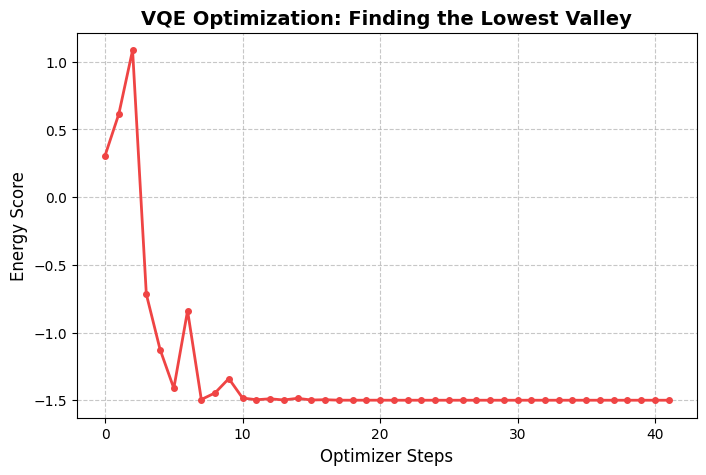

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

# --- 1. The Physics Environment (Step 3) ---
hamiltonian = SparsePauliOp.from_list([
    ("ZZ", 1.0), 
    ("XX", -0.5)
])

# --- 2. The Custom Ansatz (Step 2) ---
theta_0 = Parameter('θ0')
theta_1 = Parameter('θ1')
ansatz = QuantumCircuit(2)
ansatz.ry(theta_0, 0)
ansatz.ry(theta_1, 1)
ansatz.cx(0, 1)

# --- 3. The Estimator ---
# This acts as our bridge to calculate the Expectation Value (Energy)
estimator = StatevectorEstimator()
energy_history = []

# --- 4. THE COST FUNCTION ---
def cost_function(params):
    # Pass the current parameters (angles) to the quantum circuit
    
    pub = (ansatz, hamiltonian, params)
    job = estimator.run([pub])
    result = job.result()
    
    # ऊर्जा (Expectation Value) मिळवणे
    energy = result[0].data.evs

    # Save history for plotting
    energy_history.append(energy)
    return energy

# --- 5. THE CLASSICAL OPTIMIZER (The Brain) ---
print("Starting VQE Optimization Loop...")

# Start with random angles for θ0 and θ1
initial_dials = np.random.rand(ansatz.num_parameters) * 2 * np.pi

# Run the Scipy minimize function using the COBYLA algorithm
result = minimize(
    cost_function, 
    initial_dials, 
    method='COBYLA', 
    options={'maxiter': 100}
)

# --- 6. Results and Visualization ---
print("\n--- VQE COMPLETE ---")
print(f"Optimal Dial Settings (θ0, θ1): {result.x}")
print(f"Lowest Energy Found (Ground State): {result.fun:.4f}")

# Plotting the blindfolded hiker's path down the mountain
plt.figure(figsize=(8, 5))
plt.plot(energy_history, color='#ef4444', linewidth=2, marker='o', markersize=4)
plt.title("VQE Optimization: Finding the Lowest Valley", fontsize=14, fontweight='bold')
plt.xlabel("Optimizer Steps", fontsize=12)
plt.ylabel("Energy Score", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


## 3. Exercises (Hands-on Practice)

### Exercise 1: Watch the Hiker's First Steps

**Goal:** Prove that the starting point is completely random.

* **Task:** Run the code block 3 or 4 times in a row.
* **Observation:** Pay attention to the graph. Because `initial_dials` uses a random number generator, your "hiker" starts at a different spot on the mountain every time! Some runs might find the bottom in 20 steps, while others might take 50.

### Exercise 2: Change the Brain

**Goal:** See how different classical algorithms perform.

* **Task:** In the `minimize` function, change `method='COBYLA'` to `method='Nelder-Mead'`.
* **Observation:** Run the code again. Nelder-Mead is a different type of optimization algorithm. Look at the convergence graph—does it take a smoother path down the mountain, or a more jagged one?